# Chapter 18: Events, Queues, Agents, and Hybrid Models

*Systems Thinking with AI* by Jason Karpeles

When an aggregate model and a queue are joined, the seam between them is part of the model.

**Goal.** Four demonstrations of the chapter's staffing model and patient queue. Change how often they exchange numbers, test the queue alone, test the staffing rule alone, and check whether the frequency finding survives a different random seed.

**Demonstrations**

1. Exchange frequency is a modeling decision
2. Nine patients per period become nine arrival events
3. The staffing rule alone has an equilibrium
4. Does the frequency finding survive another seed?

The chapter's own model code is written out in full below, so the notebook runs with NumPy and Matplotlib alone. The interactive version of this chapter is at [https://karpeles.com/companions/systems-thinking-with-ai/18-hybrid/reader.html](https://karpeles.com/companions/systems-thinking-with-ai/18-hybrid/reader.html).

All example inputs are constructed teaching examples built from the chapter's own numbers.

## Setup

Imports, plus two small helpers: `%%module` runs a cell as a named module so the chapter files can import one another by their package names, and `show` draws a demonstration's figure and lists its values.

In [1]:
import os, sys, tempfile, types
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from IPython.core.magic import register_cell_magic
from IPython.display import Markdown, display

%matplotlib inline

WORKDIR = tempfile.mkdtemp(prefix="systems-thinking-")


@register_cell_magic
def module(line, cell):
    """Run a cell as a named module so the chapter code can import it by name."""
    name = line.strip()
    parts = name.split(".")
    for i in range(1, len(parts)):
        parent = ".".join(parts[:i])
        if parent not in sys.modules:
            pkg = types.ModuleType(parent)
            pkg.__path__ = []
            sys.modules[parent] = pkg
            if i > 1:
                setattr(sys.modules[".".join(parts[:i - 1])], parts[i - 1], pkg)
    mod = types.ModuleType(name)
    mod.__file__ = os.path.join(WORKDIR, *parts) + ".py"
    mod.__package__ = ".".join(parts[:-1])
    sys.modules[name] = mod
    if len(parts) > 1:
        setattr(sys.modules[".".join(parts[:-1])], parts[-1], mod)
    exec(compile(cell, name, "exec"), mod.__dict__)


def show(result):
    """Draw the figure, then list the calculated values and the reading."""
    fig, metrics, interpretation = result[:3]
    plt.show()
    display(Markdown("\n".join(f"- **{k}:** {v}" for k, v in metrics.items())))
    display(Markdown(interpretation))


def sweep(function, controls):
    """Recompute every setting offered in the interactive reader and list the values."""
    import itertools
    keys = [k for k, _ in controls]
    rows = []
    for combo in itertools.product(*[v for _, v in controls]):
        fig, metrics, _ = function(**dict(zip(keys, combo)))[:3]
        plt.close(fig)
        setting = ", ".join(f"{k} = {v}" for k, v in zip(keys, combo))
        rows.append(f"- **{setting}**: " + "; ".join(f"{k} {v}" for k, v in metrics.items()))
    display(Markdown("\n".join(rows)))


## The chapter's model code

Each cell below is one file of the chapter's code, defined under its package name. Later chapters build on earlier ones, so some files come from the chapters they cite.

`chapters/chapter_18_hybrid/code/coupling.py`

In [2]:
%%module chapters.chapter_18_hybrid.code.coupling
"""One boundary contract joining an aggregate staffing model to a patient queue.

The aggregate side carries staffing as a continuous stock. The backlog side clears
individual arrivals in batches at each hourly boundary. Neither can see inside the other.
Everything that crosses does so through one declared interface,
at a stated direction-specific frequency, in stated units.
"""

import random
import statistics
from dataclasses import dataclass


@dataclass(frozen=True)
class Interface:
    """What crosses the boundary, in which direction, and in what unit."""

    to_queue: tuple[str, ...] = ("servers",)
    to_aggregate: tuple[str, ...] = ("mean_residence", "queue_length")
    units: tuple[tuple[str, str], ...] = (
        ("servers", "clinicians"),
        ("mean_residence", "hours"),
        ("queue_length", "patients"),
    )
    exchange_every: int = 1  # hourly periods between feedback samples

    def __post_init__(self) -> None:
        if not isinstance(self.exchange_every, int) or self.exchange_every < 1:
            raise ValueError("exchange_every must be a positive integer")

    def unit_of(self, name: str) -> str:
        for key, unit in self.units:
            if key == name:
                return unit
        raise KeyError(f"'{name}' does not cross this boundary")

    def validate(self, payload: dict[str, float], direction: str) -> None:
        if direction not in ("to_queue", "to_aggregate"):
            raise ValueError("unknown interface direction")
        expected = self.to_queue if direction == "to_queue" else self.to_aggregate
        if set(payload) != set(expected):
            raise ValueError(
                f"{direction} payload must carry exactly {sorted(expected)}, got {sorted(payload)}"
            )


class AggregateStaffing:
    """Staff level closes part of the gap to a target derived from observed residence."""

    def __init__(self, staff: float = 10.0, adjustment_time: float = 4.0,
                 target_residence: float = 0.5) -> None:
        if adjustment_time <= 0 or target_residence <= 0:
            raise ValueError("adjustment_time and target_residence must be positive")
        self.staff = float(staff)
        self.baseline = float(staff)
        self.adjustment_time = adjustment_time
        self.target_residence = target_residence

    def step(self, mean_residence: float, dt: float = 1.0) -> float:
        """Adjust staffing toward what the observed residence implies is needed.

        The target is anchored to the baseline establishment, not to whatever
        staffing happens to be now. A rule that multiplies the current level has
        no equilibrium: it drifts geometrically and never settles.
        """
        desired = self.baseline * (mean_residence / self.target_residence)
        desired = min(desired, self.baseline * 3.0)
        self.staff += dt * (desired - self.staff) / self.adjustment_time
        self.staff = max(1.0, self.staff)
        return self.staff


class PatientQueue:
    """A batch-clearing backlog proxy with arrival-to-clearance residence times.

    One period is one hour. Capacity is rounded servers * dt / service_time.
    The oldest arrivals are cleared at each period end; individual service starts
    and completions are not scheduled. This is not a discrete-event queue.
    """

    def __init__(self, arrivals_per_period: float, service_time: float, seed: int) -> None:
        if arrivals_per_period < 0 or service_time <= 0:
            raise ValueError("arrivals non-negative, service_time positive")
        self.arrivals = arrivals_per_period
        self.service_time = service_time
        self.rng = random.Random(seed)
        self.waiting: list[float] = []

    def step(self, servers: int, now: float, dt: float = 1.0) -> dict[str, float]:
        if dt <= 0:
            raise ValueError("dt must be positive")
        if servers < 1:
            raise ValueError("a queue needs at least one server")
        for _ in range(int(round(self.arrivals * dt))):
            self.waiting.append(now + self.rng.random() * dt)
        self.waiting.sort()
        capacity = int(round(servers * dt / self.service_time))
        served = self.waiting[:capacity]
        self.waiting = self.waiting[capacity:]
        waits = [(now + dt) - t for t in served]
        return {
            "mean_residence": statistics.fmean(waits) if waits else 0.0,
            "queue_length": float(len(self.waiting)),
        }


def run_coupled(periods: int, interface: Interface | None = None, seed: int = 3
                ) -> dict[str, list[float]]:
    """Send staffing every hour and sample backlog feedback at the declared interval."""
    if periods < 1:
        raise ValueError("periods must be at least 1")
    interface = interface or Interface()
    staffing = AggregateStaffing()
    queue = PatientQueue(arrivals_per_period=9.0, service_time=1.0, seed=seed)
    history: dict[str, list[float]] = {"staff": [], "mean_residence": [], "queue_length": []}
    feedback = {"mean_residence": 0.0, "queue_length": 0.0}
    for period in range(periods):
        to_queue = {"servers": staffing.staff}
        interface.validate(to_queue, "to_queue")
        observed = queue.step(servers=max(1, int(round(to_queue["servers"]))), now=float(period))
        interface.validate(observed, "to_aggregate")
        if period % interface.exchange_every == 0:
            feedback = observed
        staffing.step(feedback["mean_residence"])
        history["staff"].append(staffing.staff)
        history["mean_residence"].append(observed["mean_residence"])
        history["queue_length"].append(observed["queue_length"])
    return history


Formatting and plotting helpers used by the demonstrations (`readerkit`).

In [3]:
%%module readerkit
"""Formatting and plotting helpers shared by the demonstrations."""
from __future__ import annotations

import math

# Restrained palette with good contrast on white. Use direct labels, not
# colour alone, to distinguish series.
PALETTE = {
    "ink": "#172a3b",
    "teal": "#136f75",
    "gold": "#8f5d0f",
    "navy": "#334c72",
    "terracotta": "#a24a33",
    "olive": "#5d6a37",
    "grey": "#6b757b",
    "light": "#c9d3d6",
}

FONT_SIZE = 11.5
SMALL_FONT = 10.5


def new_figure(ncols=1, width=None, height=4.3):
    """Return (fig, axes) with constrained layout and the house size.

    One panel is 6.6 x 4.3 inches; two panels are 10.4 x 4.3 inches. At the
    reader's display width this keeps 11 to 12 point text legible.
    """
    import matplotlib.pyplot as plt

    if width is None:
        width = 6.6 if ncols == 1 else 10.4
    fig, axes = plt.subplots(1, ncols, figsize=(width, height), layout="constrained")
    for ax in (axes if ncols > 1 else [axes]):
        ax.grid(alpha=0.18)
    return fig, axes


def fmt(value, digits=2):
    """Format a finite number with a fixed number of decimals.

    Returns the string "undefined" for None. Raises ValueError for NaN or
    infinity, because a reader must be told why a value is undefined; use
    ``undefined(reason)`` for that.
    """
    if value is None:
        return "undefined"
    value = float(value)
    if not math.isfinite(value):
        raise ValueError("non-finite value; state why it is undefined with undefined(reason)")
    text = f"{value:.{digits}f}"
    if text.startswith("-") and float(text) == 0:
        text = text[1:]
    return text


def signed(value, digits=2):
    """Format a number for use inside a written calculation: negatives get parentheses."""
    text = fmt(value, digits)
    return f"({text})" if text.startswith("-") else text


def undefined(reason):
    """Display string for a quantity that has no value in this state."""
    return f"undefined ({reason})"


def is_tie(a, b, tol=1e-9):
    return abs(float(a) - float(b)) <= tol


def argmax_set(scores, tol=1e-9):
    """Names whose score is within tol of the maximum. ``scores`` is a dict."""
    best = max(scores.values())
    return [name for name, value in scores.items() if abs(value - best) <= tol]


def label_point(ax, x, y, text, color=None, dx=6, dy=6, ha="left", va="bottom", size=None):
    """Directly label a point with an offset in points (no arrow)."""
    return ax.annotate(
        text,
        (x, y),
        xytext=(dx, dy),
        textcoords="offset points",
        ha=ha,
        va=va,
        color=color or PALETTE["ink"],
        fontsize=size or SMALL_FONT,
    )


## Demonstration functions

Each function below runs the chapter's model for one demonstration and returns a figure, the calculated values and a worked reading of them.

In [4]:
"""Chapter 18 reader: an aggregate staffing model joined to a patient queue through one declared seam.

Every number comes from the Chapter 18 pack (Interface, AggregateStaffing, PatientQueue,
run_coupled). All random draws use the fixed seeds named in each control or in the text.
"""
from __future__ import annotations

import statistics

import numpy as np
from readerkit import PALETTE, fmt, label_point, new_figure, signed

from chapters.chapter_18_hybrid.code.coupling import (
    AggregateStaffing,
    Interface,
    PatientQueue,
    run_coupled,
)

EQ_FAST = "run_coupled(periods=60, interface=Interface(exchange_every=1), seed=5)"
EQ_SLOW = "run_coupled(periods=60, interface=Interface(exchange_every=8), seed=5)"


def _volatility(staff):
    return statistics.pstdev(staff)


# Demonstration 1: how often the two halves talk.

def exchange_frequency(exchange_every=8):
    fast = run_coupled(periods=60, interface=Interface(exchange_every=1), seed=5)
    chosen = run_coupled(periods=60, interface=Interface(exchange_every=exchange_every), seed=5)
    staff = chosen["staff"]
    vol, vol_fast = _volatility(staff), _volatility(fast["staff"])
    wait, wait_fast = statistics.fmean(chosen["mean_residence"]), statistics.fmean(fast["mean_residence"])
    xs = np.arange(1, 61)

    fig, ax = new_figure()
    ax.axhline(10, color=PALETTE["grey"], linestyle="dashed", linewidth=1.3)
    ax.plot(xs, fast["staff"], color=PALETTE["light"], linewidth=1.6)
    ax.plot(xs, staff, color=PALETTE["navy"], linewidth=2.2)
    label_point(ax, 1, 10, "Baseline of 10", color=PALETTE["grey"], dx=2, dy=-14, va="top")
    label_point(ax, 60, 33, f"Dark: exchange every {fmt(exchange_every, 0)}; pale: every 1", color=PALETTE["ink"],
                dx=0, dy=0, ha="right", va="top")
    ax.set_xlim(0, 61)
    ax.set_ylim(0, 34)
    ax.set_xlabel("Period")
    ax.set_ylabel("Staff (clinicians)")

    low, high = min(staff), max(staff)
    low_f, high_f = min(fast["staff"]), max(fast["staff"])
    ratio = vol / vol_fast
    span, span_f = round(high, 1) - round(low, 1), round(high_f, 1) - round(low_f, 1)
    dwait = round(wait, 2) - round(wait_fast, 2)
    metrics = {
        "Exchange every (periods)": fmt(exchange_every, 0),
        "Staffing volatility": fmt(vol, 2),
        "Staff range": f"{fmt(low, 1)} to {fmt(high, 1)}",
        "Mean residence (hours)": fmt(wait, 2),
        "Volatility against exchanging every period": fmt(ratio, 2),
    }
    if exchange_every == 1:
        tail = "This is the reference run, so the ratio is exactly 1."
    else:
        tail = (f"The rule corrects against a residence time measured up to {fmt(exchange_every - 1, 0)} period{'' if exchange_every == 2 else 's'} ago, an information "
                f"delay inside a feedback loop.")
    interpretation = (
        f"Volatility ratio = {fmt(vol, 4)}/{fmt(vol_fast, 4)} = {fmt(ratio, 2)} (unrounded volatilities). Staff range {fmt(high, 1)} - {fmt(low, 1)} = "
        f"{fmt(span, 1)} against {fmt(high_f, 1)} - {fmt(low_f, 1)} = {fmt(span_f, 1)} when exchanging every period. "
        f"Mean residence {fmt(wait, 2)} against {fmt(wait_fast, 2)}, a difference of {signed(dwait, 2)} hours. {tail}"
    )
    alt = (f"Staffing over 60 periods with seed 5, exchanging every {fmt(exchange_every, 0)} period(s) in dark blue "
           f"over a pale line for exchanging every period; the dark path ranges from {fmt(low, 1)} to {fmt(high, 1)}.")
    return fig, metrics, interpretation, alt


# Demonstration 2: the queue side on its own.

def queue_alone(servers=9, arrivals=9.0):
    periods = 12
    queue = PatientQueue(arrivals_per_period=float(arrivals), service_time=1.0, seed=5)
    rows = [queue.step(servers=int(servers), now=float(t)) for t in range(periods)]
    lengths = [r["queue_length"] for r in rows]
    waits = [r["mean_residence"] for r in rows]
    xs = np.arange(1, periods + 1)

    fig, (left, right) = new_figure(ncols=2)
    left.plot(xs, lengths, marker="o", color=PALETTE["terracotta"], linewidth=2)
    left.annotate(fmt(lengths[-1], 0), (xs[-1], lengths[-1]), xytext=(-4, 9), textcoords="offset points",
                  ha="right", fontsize=10.5, color=PALETTE["terracotta"])
    left.set_xlim(0.5, 12.5)
    left.set_ylim(-2, 48)
    left.set_xlabel("Period")
    left.set_ylabel("Patients waiting at period end")
    right.plot(xs, waits, marker="o", color=PALETTE["navy"], linewidth=2)
    right.annotate(fmt(waits[-1], 2), (xs[-1], waits[-1]), xytext=(-4, 9), textcoords="offset points",
                   ha="right", fontsize=10.5, color=PALETTE["navy"])
    right.set_xlim(0.5, 12.5)
    right.set_ylim(0, 6)
    right.set_xlabel("Period")
    right.set_ylabel("Mean residence of those cleared (hours)")

    growth = arrivals - servers
    if growth > 0:
        expected = periods * growth
        calc = (f"Backlog grows by {fmt(arrivals, 0)} - {fmt(servers, 0)} = {fmt(growth, 0)} per period, so after "
                f"{fmt(periods, 0)} periods it is {fmt(periods, 0)} x {fmt(growth, 0)} = {fmt(expected, 0)} patients")
        tail = "Capacity is below arrivals, so waiting keeps growing."
    elif growth == 0:
        expected = 0
        calc = (f"Backlog change per period is {fmt(arrivals, 0)} - {fmt(servers, 0)} = 0, so it stays at 0 patients")
        tail = "Capacity equals arrivals exactly, a tie: nothing queues, and the residence time is only the spread of arrival times within a period."
    else:
        expected = 0
        calc = (f"Capacity exceeds arrivals by {fmt(servers, 0)} - {fmt(arrivals, 0)} = {fmt(-growth, 0)}, so the backlog stays at 0 patients")
        tail = "Spare capacity is not used, so the residence time does not fall below the spread of arrival times within a period."
    assert abs(lengths[-1] - expected) < 1e-9
    metrics = {
        "Arrivals per period": fmt(arrivals, 0),
        "Servers": fmt(servers, 0),
        "Patients waiting after 12 periods": fmt(lengths[-1], 0),
        "Mean residence in the last period (hours)": fmt(waits[-1], 2),
        "Mean residence in the first period (hours)": fmt(waits[0], 2),
    }
    interpretation = f"{calc}. Mean residence of those cleared went from {fmt(waits[0], 2)} to {fmt(waits[-1], 2)} hours. {tail}"
    alt = (f"Two panels over 12 periods with {fmt(arrivals, 0)} arrivals and {fmt(servers, 0)} servers: patients waiting "
           f"end at {fmt(lengths[-1], 0)} and the mean residence ends at {fmt(waits[-1], 2)} hours.")
    return fig, metrics, interpretation, alt


# Demonstration 3: the aggregate side on its own, with a constant wait.

def aggregate_alone(wait=0.5, adjustment_time=4.0):
    staffing = AggregateStaffing(staff=10.0, adjustment_time=float(adjustment_time), target_residence=0.5)
    path = [staffing.staff]
    for _ in range(40):
        path.append(staffing.step(wait))
    desired_raw = 10.0 * (wait / 0.5)
    desired = min(desired_raw, 30.0)
    first = 10.0 + (desired - 10.0) / adjustment_time
    assert abs(path[1] - first) < 1e-9
    xs = np.arange(41)

    fig, ax = new_figure()
    ax.axhline(desired, color=PALETTE["grey"], linestyle="dashed", linewidth=1.4)
    ax.plot(xs, path, color=PALETTE["navy"], linewidth=2.2)
    label_point(ax, 40, desired, f"Target {fmt(desired, 1)}", color=PALETTE["grey"], dx=-2, dy=6, ha="right")
    ax.set_xlim(0, 41)
    ax.set_ylim(0, 34)
    ax.set_xlabel("Period (the residence time is held constant)")
    ax.set_ylabel("Staff (clinicians)")

    remaining = round(desired, 1) - round(path[-1], 2)
    metrics = {
        "Staff the rule aims at": fmt(desired, 1),
        "Staff after 1 period": fmt(path[1] + 1e-9, 2),  # round half up, so 10.625 shows as 10.63
        "Staff after 40 periods": fmt(path[-1], 2),
        "Gap still open after 40 periods": signed(remaining, 2),
    }
    if abs(desired_raw - desired) > 1e-9:
        note = (f" The wait implies {fmt(desired_raw, 1)}, but the rule caps the target at three times the baseline, "
                f"3 x 10 = 30, so it stops there.")
    elif abs(desired - 10.0) < 1e-9:
        note = " The wait equals the target wait, so the gap is 0 and staffing does not move."
    else:
        note = ""
    interpretation = (
        f"Target = 10 x ({fmt(wait, 2)}/0.5) = {fmt(desired_raw, 1)}.{note} First period: 10 + ({fmt(desired, 1)} - 10)/"
        f"{fmt(adjustment_time, 0)} = {fmt(first + 1e-9, 2)}. After 40 periods staff is {fmt(path[-1], 2)}, leaving a gap of "
        f"{fmt(desired, 1)} - {fmt(path[-1], 2)} = {signed(remaining, 2)}. " + ("With no gap, the adjustment time has nothing to act on." if abs(desired - 10.0) < 1e-9 else "A slower adjustment time closes the gap more slowly.") + ""
    )
    alt = (f"Staffing from a baseline of 10 under a constant wait of {fmt(wait, 2)} hours and an adjustment time of "
           f"{fmt(adjustment_time, 0)}, approaching a dashed target of {fmt(desired, 1)}.")
    return fig, metrics, interpretation, alt


# Demonstration 4: does the exchange-frequency conclusion survive another seed?

def seed_check(seed=5, periods=60):
    fast = run_coupled(periods=periods, interface=Interface(exchange_every=1), seed=seed)["staff"]
    slow = run_coupled(periods=periods, interface=Interface(exchange_every=8), seed=seed)["staff"]
    vf, vs = _volatility(fast), _volatility(slow)
    xs = np.arange(1, periods + 1)
    ratio = vs / vf

    fig, ax = new_figure()
    ax.axhline(10, color=PALETTE["grey"], linestyle="dashed", linewidth=1.2)
    ax.plot(xs, fast, color=PALETTE["teal"], linewidth=2)
    ax.plot(xs, slow, color=PALETTE["terracotta"], linewidth=2)
    top = max(max(slow), max(fast)) + 3
    ax.set_ylim(0, top)
    ax.set_xlim(0, periods + 1)
    label_point(ax, periods, top - 0.5, "Teal: every period; red: every 8", color=PALETTE["ink"], dx=0, dy=0,
                ha="right", va="top")
    ax.set_xlabel("Period")
    ax.set_ylabel("Staff (clinicians)")

    if ratio >= 2.0:
        verdict = "The slower exchange swings clearly wider, as the chapter's run does."
    else:
        verdict = ("The slower exchange swings wider, but by much less than in the chapter's run, so the size of the "
                   "effect depends on the seed and the conclusion needs several seeds.")
    metrics = {
        "Volatility, every period": fmt(vf, 2),
        "Volatility, every 8 periods": fmt(vs, 2),
        "Ratio": fmt(ratio, 2),
        "Chapter's seed 5 over 60 periods": "0.88 and 4.75",
    }
    interpretation = (
        f"Ratio = {fmt(vs, 4)}/{fmt(vf, 4)} = {fmt(ratio, 2)} for seed {fmt(seed, 0)} over {fmt(periods, 0)} periods. "
        f"The chapter's seed 5 over 60 periods gives volatilities 0.88 and 4.75, about 5.4 times. {verdict}"
    )
    alt = (f"Staffing paths for seed {fmt(seed, 0)} over {fmt(periods, 0)} periods, exchanging every period in teal and every "
           f"eighth period in red; the volatility ratio is {fmt(ratio, 2)}.")
    return fig, metrics, interpretation, alt


## 1. Exchange frequency is a modeling decision

*If only the exchange interval changes, how different is the staffing the coupled model produces?*

A stale reading is an information delay inside a feedback loop. The rule keeps acting on an old residence time, so staffing overshoots and swings on the interval's own period.

    run_coupled(periods=60, interface=Interface(exchange_every=1), seed=5)
    run_coupled(periods=60, interface=Interface(exchange_every=8), seed=5)

**Symbols and inputs.** Staff is the number of clinicians in the aggregate model. The backlog side receives nine patients per hourly period and clears them in batches at each hourly boundary. Exchanging every k periods means the staffing rule sees a mean residence time refreshed only every k periods; server counts still cross every period. Volatility is the standard deviation of staff over the 60 periods; residence is in hours.

**Predict first.** Does exchanging every 8 periods give a larger staffing range than exchanging every period?

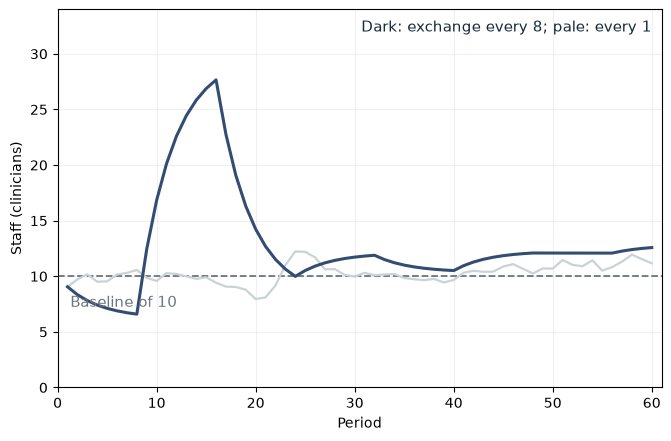

- **Exchange every (periods):** 8
- **Staffing volatility:** 4.75
- **Staff range:** 6.6 to 27.7
- **Mean residence (hours):** 0.61
- **Volatility against exchanging every period:** 5.42

Volatility ratio = 4.7458/0.8761 = 5.42 (unrounded volatilities). Staff range 27.7 - 6.6 = 21.1 against 12.2 - 7.9 = 4.3 when exchanging every period. Mean residence 0.61 against 0.52, a difference of 0.09 hours. The rule corrects against a residence time measured up to 7 periods ago, an information delay inside a feedback loop.

In [5]:
show(exchange_frequency(exchange_every=8))

**Use the idea.** Choose the exchange interval from the system's timescales and write it beside the equations.

**Where the conclusion applies.** One seed, 60 periods and the chapter's rule. Neither run settles; an interval picked for speed can report a behaviour that belongs to the interval.

*Constructed example: the chapter's own two runs with seed 5, plus intervals 2 and 4 defined for this reader.*

Every setting the interactive reader offers for this demonstration:

In [6]:
sweep(exchange_frequency, [('exchange_every', [1, 2, 4, 8])])

- **exchange_every = 1**: Exchange every (periods) 1; Staffing volatility 0.88; Staff range 7.9 to 12.2; Mean residence (hours) 0.52; Volatility against exchanging every period 1.00
- **exchange_every = 2**: Exchange every (periods) 2; Staffing volatility 0.90; Staff range 8.3 to 12.4; Mean residence (hours) 0.52; Volatility against exchanging every period 1.03
- **exchange_every = 4**: Exchange every (periods) 4; Staffing volatility 1.42; Staff range 7.4 to 13.8; Mean residence (hours) 0.53; Volatility against exchanging every period 1.62
- **exchange_every = 8**: Exchange every (periods) 8; Staffing volatility 4.75; Staff range 6.6 to 27.7; Mean residence (hours) 0.61; Volatility against exchanging every period 5.42

## 2. Nine patients per period become nine arrival events

*With the staffing side held fixed, how does the queue behave as capacity moves relative to arrivals?*

Going down the seam, an aggregate rate becomes individual events. Each period that capacity falls short of arrivals adds the shortfall to the queue.

    run_coupled(periods=60, interface=Interface(exchange_every=1), seed=5)

**Symbols and inputs.** Arrivals are patients per period, each given a random time inside the period. Each server clears one patient per period at the period's end. Waiting is patients still in the backlog at the end of a period; residence is in hours, from arrival to the end of the period in which a patient is cleared.

**Predict first.** With 9 arrivals and 8 servers, how many patients are waiting after 12 periods?

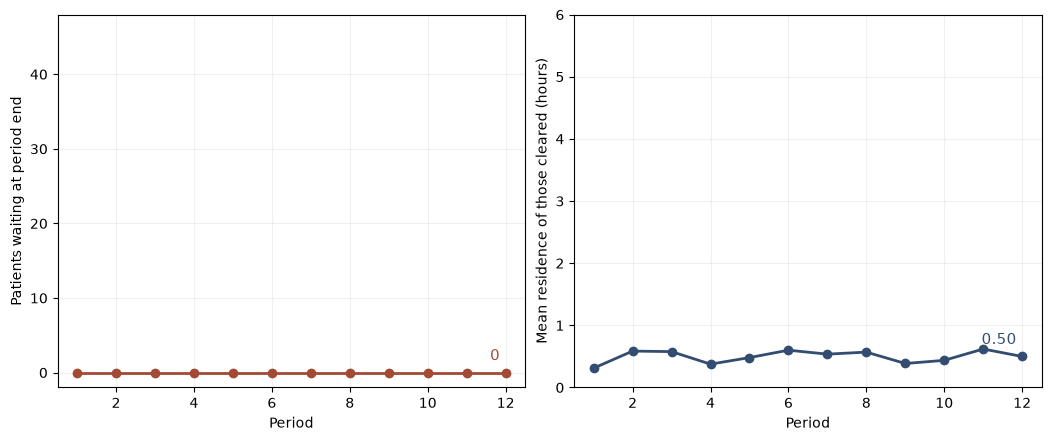

- **Arrivals per period:** 9
- **Servers:** 9
- **Patients waiting after 12 periods:** 0
- **Mean residence in the last period (hours):** 0.50
- **Mean residence in the first period (hours):** 0.31

Backlog change per period is 9 - 9 = 0, so it stays at 0 patients. Mean residence of those cleared went from 0.31 to 0.50 hours. Capacity equals arrivals exactly, a tie: nothing queues, and the residence time is only the spread of arrival times within a period.

In [7]:
show(queue_alone(servers=9, arrivals=9.0))

**Use the idea.** Test the queue with a constant server count before closing the loop, so a defect is not hidden inside the coupling.

**Where the conclusion applies.** Seed 5, one hour per service, 12 periods, and arrivals spread evenly at random within a period. Spreading them differently would change the waits, which the chapter notes is a modelling choice.

*Constructed example: the chapter's patient queue with arrival and server counts defined for this reader.*

Every setting the interactive reader offers for this demonstration:

In [8]:
sweep(queue_alone, [('servers', [7, 8, 9]), ('arrivals', [9.0, 10.0])])

- **servers = 7, arrivals = 9.0**: Arrivals per period 9; Servers 7; Patients waiting after 12 periods 24; Mean residence in the last period (hours) 3.01; Mean residence in the first period (hours) 0.38
- **servers = 7, arrivals = 10.0**: Arrivals per period 10; Servers 7; Patients waiting after 12 periods 36; Mean residence in the last period (hours) 3.93; Mean residence in the first period (hours) 0.42
- **servers = 8, arrivals = 9.0**: Arrivals per period 9; Servers 8; Patients waiting after 12 periods 12; Mean residence in the last period (hours) 1.87; Mean residence in the first period (hours) 0.34
- **servers = 8, arrivals = 10.0**: Arrivals per period 10; Servers 8; Patients waiting after 12 periods 24; Mean residence in the last period (hours) 2.90; Mean residence in the first period (hours) 0.38
- **servers = 9, arrivals = 9.0**: Arrivals per period 9; Servers 9; Patients waiting after 12 periods 0; Mean residence in the last period (hours) 0.50; Mean residence in the first period (hours) 0.31
- **servers = 9, arrivals = 10.0**: Arrivals per period 10; Servers 9; Patients waiting after 12 periods 12; Mean residence in the last period (hours) 1.61; Mean residence in the first period (hours) 0.34

## 3. The staffing rule alone has an equilibrium

*With the residence time held constant, where does the staffing rule settle and how fast?*

The target is anchored to the baseline, not the current staff, so a constant wait gives a constant target and the staff moves smoothly toward it.

    run_coupled(periods=60, interface=Interface(exchange_every=1), seed=5)

**Symbols and inputs.** Staff starts at the baseline of 10. The target is 10 times the mean residence time over the target residence of 0.5 hours, capped at three times the baseline. Each period staff closes 1/(adjustment time) of the gap.

**Predict first.** If the residence time is held at 0.75 hours, what staffing level does the rule head toward?

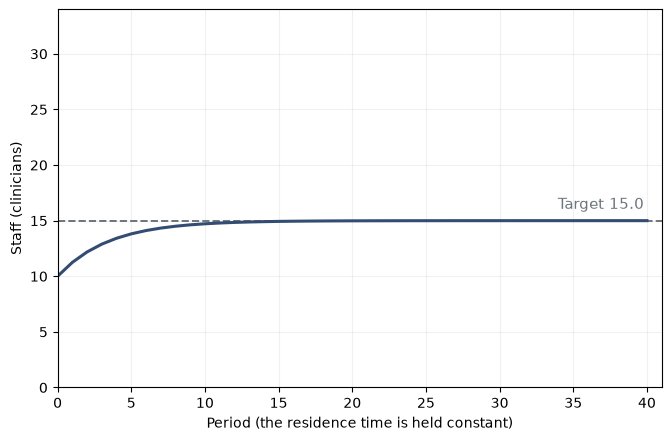

- **Staff the rule aims at:** 15.0
- **Staff after 1 period:** 11.25
- **Staff after 40 periods:** 15.00
- **Gap still open after 40 periods:** 0.00

Target = 10 x (0.75/0.5) = 15.0. First period: 10 + (15.0 - 10)/4 = 11.25. After 40 periods staff is 15.00, leaving a gap of 15.0 - 15.00 = 0.00. A slower adjustment time closes the gap more slowly.

In [9]:
show(aggregate_alone(wait=0.75, adjustment_time=4.0))

**Use the idea.** A constant input should give a stable output; if the aggregate side alone cannot settle, no coupling can fix it.

**Where the conclusion applies.** The residence time is an input held fixed, which the coupled model never does. The cap and the floor of one clinician are the chapter's rules, not facts about clinics.

*Constructed example: the chapter's staffing rule with the three constant waits of the chapter's test and others defined for this reader.*

Every setting the interactive reader offers for this demonstration:

In [10]:
sweep(aggregate_alone, [('wait', [0.25, 0.5, 0.75, 2.0]), ('adjustment_time', [4.0, 8.0])])

- **wait = 0.25, adjustment_time = 4.0**: Staff the rule aims at 5.0; Staff after 1 period 8.75; Staff after 40 periods 5.00; Gap still open after 40 periods 0.00
- **wait = 0.25, adjustment_time = 8.0**: Staff the rule aims at 5.0; Staff after 1 period 9.38; Staff after 40 periods 5.02; Gap still open after 40 periods (-0.02)
- **wait = 0.5, adjustment_time = 4.0**: Staff the rule aims at 10.0; Staff after 1 period 10.00; Staff after 40 periods 10.00; Gap still open after 40 periods 0.00
- **wait = 0.5, adjustment_time = 8.0**: Staff the rule aims at 10.0; Staff after 1 period 10.00; Staff after 40 periods 10.00; Gap still open after 40 periods 0.00
- **wait = 0.75, adjustment_time = 4.0**: Staff the rule aims at 15.0; Staff after 1 period 11.25; Staff after 40 periods 15.00; Gap still open after 40 periods 0.00
- **wait = 0.75, adjustment_time = 8.0**: Staff the rule aims at 15.0; Staff after 1 period 10.63; Staff after 40 periods 14.98; Gap still open after 40 periods 0.02
- **wait = 2.0, adjustment_time = 4.0**: Staff the rule aims at 30.0; Staff after 1 period 15.00; Staff after 40 periods 30.00; Gap still open after 40 periods 0.00
- **wait = 2.0, adjustment_time = 8.0**: Staff the rule aims at 30.0; Staff after 1 period 12.50; Staff after 40 periods 29.90; Gap still open after 40 periods 0.10

## 4. Does the frequency finding survive another seed?

*If the random seed changes, does exchanging less often still multiply the staffing swing?*

The chapter reports one seed. Another seed gives different arrival times and, with them, a different size of effect, so a single pair of runs does not settle the matter.

    run_coupled(periods=60, interface=Interface(exchange_every=1), seed=5)
    run_coupled(periods=60, interface=Interface(exchange_every=8), seed=5)

**Symbols and inputs.** A seed fixes the random arrival times. Volatility is the standard deviation of staff. The ratio is the volatility with an exchange every 8 periods divided by the volatility with an exchange every period.

**Predict first.** With seed 7 over 60 periods, is the volatility ratio near the chapter's 5.4?

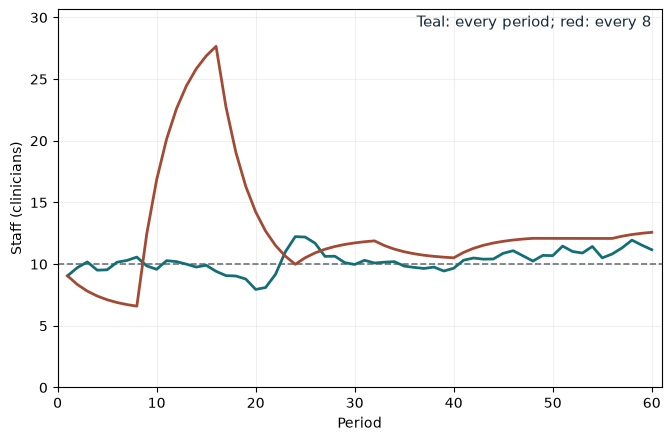

- **Volatility, every period:** 0.88
- **Volatility, every 8 periods:** 4.75
- **Ratio:** 5.42
- **Chapter's seed 5 over 60 periods:** 0.88 and 4.75

Ratio = 4.7458/0.8761 = 5.42 for seed 5 over 60 periods. The chapter's seed 5 over 60 periods gives volatilities 0.88 and 4.75, about 5.4 times. The slower exchange swings clearly wider, as the chapter's run does.

In [11]:
show(seed_check(seed=5, periods=60))

**Use the idea.** Where a finding depends on the exchange interval, report it across several seeds, as the chapter suggests for the frequency.

**Where the conclusion applies.** Four seeds and two run lengths; this is a robustness check on a constructed model, not an estimate of how real clinics behave.

*Constructed example: the chapter's two coupled runs repeated with other seeds and run lengths defined for this reader.*

Every setting the interactive reader offers for this demonstration:

In [12]:
sweep(seed_check, [('seed', [3, 5, 7, 9]), ('periods', [30, 60])])

- **seed = 3, periods = 30**: Volatility, every period 0.73; Volatility, every 8 periods 0.80; Ratio 1.10; Chapter's seed 5 over 60 periods 0.88 and 4.75
- **seed = 3, periods = 60**: Volatility, every period 0.59; Volatility, every 8 periods 3.20; Ratio 5.40; Chapter's seed 5 over 60 periods 0.88 and 4.75
- **seed = 5, periods = 30**: Volatility, every period 0.98; Volatility, every 8 periods 6.47; Ratio 6.61; Chapter's seed 5 over 60 periods 0.88 and 4.75
- **seed = 5, periods = 60**: Volatility, every period 0.88; Volatility, every 8 periods 4.75; Ratio 5.42; Chapter's seed 5 over 60 periods 0.88 and 4.75
- **seed = 7, periods = 30**: Volatility, every period 0.83; Volatility, every 8 periods 1.13; Ratio 1.36; Chapter's seed 5 over 60 periods 0.88 and 4.75
- **seed = 7, periods = 60**: Volatility, every period 0.80; Volatility, every 8 periods 1.39; Ratio 1.73; Chapter's seed 5 over 60 periods 0.88 and 4.75
- **seed = 9, periods = 30**: Volatility, every period 0.49; Volatility, every 8 periods 0.94; Ratio 1.92; Chapter's seed 5 over 60 periods 0.88 and 4.75
- **seed = 9, periods = 60**: Volatility, every period 0.55; Volatility, every 8 periods 1.06; Ratio 1.91; Chapter's seed 5 over 60 periods 0.88 and 4.75

## Exercises

Try each before opening the answer. The settings above let you check the numbers.

### Exercise 1

If the interval is 8 periods, how old can the residence time the rule acts on be, at most?

<details><summary>Answer</summary>

8 - 1 = 7 periods old, just before the next exchange.

</details>

### Exercise 2

With 10 arrivals and 8 servers, how many patients wait after 12 periods?

<details><summary>Answer</summary>

(10 - 8) x 12 = 24 patients.

</details>

### Exercise 3

If the residence time is held at 0.25 hours, what staffing does the rule head toward?

<details><summary>Answer</summary>

10 x (0.25/0.5) = 5 clinicians.

</details>

---

From *Systems Thinking with AI* by Jason Karpeles. Copyright Jason Karpeles. All rights reserved.

Interactive companion: https://karpeles.com/companions/systems-thinking-with-ai/